# Contrastive Learning — AdaptMap (Paper Faithful)

Implementazione PyTorch Lightning **completamente fedele** al paper:
> Thor & Nettelblad (2025) — *"Dimensionality Reduction of Genetic Data using Contrastive Learning"*

---

### Differenze rispetto a `contrastive_adaptmap.ipynb`

| Componente | Versione naïve | Versione paper-faithful |
|---|---|---|
| **Loss** (bug critico) | `log(1+clamp(term))` per-pair | `log(1 + Σ_i term_i)` — somma **dentro** il log (Eq. 6) |
| **Batch size** | 128 (mini-batch, 5 iter/epoch) | **Full-batch** (`len(X_train)`) — 1 iter/epoch |
| **Negativi** | 127 per anchor | **N_train − 1** per anchor (tutti gli altri) |
| **Optimizer** | AdamW | **Adam** β₁=0.9, β₂=0.999 (nessun weight decay) |
| **LR decay** | ExponentialLR ogni epoch | **StepLR** γ=0.99 ogni **10 epoche** |
| **Augmentation** | flip=mask=0.90, U(0.001,·) | flip=mask=0.99, **U(0.01, 0.99)** |
| **Epochs** | 100 | **5000** |


## 📦 Installazione Dipendenze

In [1]:
# !pip install pytorch-lightning bed-reader scikit-learn matplotlib seaborn pandas numpy


## 📚 Import

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, silhouette_score, davies_bouldin_score
from bed_reader import open_bed
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

pl.seed_everything(42)
print(f"PyTorch:           {torch.__version__}")
print(f"PyTorch Lightning: {pl.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")


import sys
# Repo root importabile per importare il package contrastive_learning
sys.path.insert(0, os.path.dirname(os.getcwd()))

from contrastive_learning import (
    GenomicDataModule,
    GeneticAugmentation,
    GeneticEncoder,
    CentroidNPairLoss,
    ContrastiveGeneticModel,
    run_experiment,
    extract_embeddings,
    compute_metrics,
    equal_earth_projection,
    plot_distribution,
    plot_embedding,
    plot_confusion_matrix,
)


## 🧬 Core implementation

La logica core (DataModule, augmentation, encoder, loss, modello,
`run_experiment`, metriche e plotting) è stata estratta nel package
`contrastive_learning` e importata nella cella degli import.

Restano inline solo: configurazione, esecuzione, visualizzazione e
Integrated Gradients / attribuzione.


## ⚙️ Configurazione — Paper Faithful

In [10]:
BED_PATH          = "../data/ADAPTmap_genotypeTOP_20160222_full.bed"
SAMPLES_PER_CLASS = 30

config = {
    # === Architettura ===
    'embedding_dim':     3,        # paper: sfera 3D

    # === Augmentation — paper: U(0.01, 0.99) ===
    'flip_max':          0.99,     # p_flip_max
    'mask_max':          0.99,     # p_mask_max

    # === Optimizer — paper: Adam β₁=0.9, β₂=0.999, lr=0.001 ===
    'learning_rate':     0.001,
    'lr_decay_factor':   0.99,     # paper: decay 0.99
    'lr_decay_interval': 10,       # paper: ogni 10 iterazioni

    # === Training — paper: 5000 epoche, full-batch ===
    'max_epochs':        5000,
    'k_folds':           3,

    # === Hardware ===
    'accelerator':  'gpu' if torch.cuda.is_available() else 'cpu',
    'devices':      1,
}

# batch_size NON è nel config: viene determinato dinamicamente
# in run_experiment come len(X_train) — paper: full-batch

print("✅ Config paper-faithful:")
for k, v in config.items():
    print(f"   {k:25s}: {v}")

dm = GenomicDataModule(
    bed_path              = BED_PATH,
    batch_size            = 2048,          # full-batch
    maf_thresh            = 0.01,          # (allineato con VAE che usa 0.01)
    geno_thresh           = 0.1,           # (allineato con VAE che usa 0.1)
    min_samples_per_class = SAMPLES_PER_CLASS,
    ld_pruning            = True,
    ld_threshold          = 0.2,
    ld_window             = 50,
    val_split             = 0.15,
    test_split            = 0.15,
    downsample_per_class  = None,          # (il VAE non faceva downsampling prima del QC, rimuovendolo allineiamo i calcoli MAF)
)
dm.setup()


✅ Config paper-faithful:
   embedding_dim            : 3
   flip_max                 : 0.99
   mask_max                 : 0.99
   learning_rate            : 0.001
   lr_decay_factor          : 0.99
   lr_decay_interval        : 10
   max_epochs               : 5000
   k_folds                  : 3
   accelerator              : gpu
   devices                  : 1

CARICAMENTO: ../data/ADAPTmap_genotypeTOP_20160222_full.bed
📊 Shape iniziale: (4653, 53347)
🔍 Razze ≥30 campioni: 34/144

🧬 QC PIPELINE
   1. Missingness: 51205 SNP rimasti
   2. Imputazione: OK
   3. MAF: 51201 SNP rimasti
   4. LD Pruning (window=50, r²>0.2)...
      Rimossi 4748 SNP → 46453 rimasti

📈 FINALI: (2976, 46453)
🏷️  Razze: 34 | SNP: 46453 | Campioni: 2976
   Train 2083 | Val 446 | Test 447
✅ Setup completato!


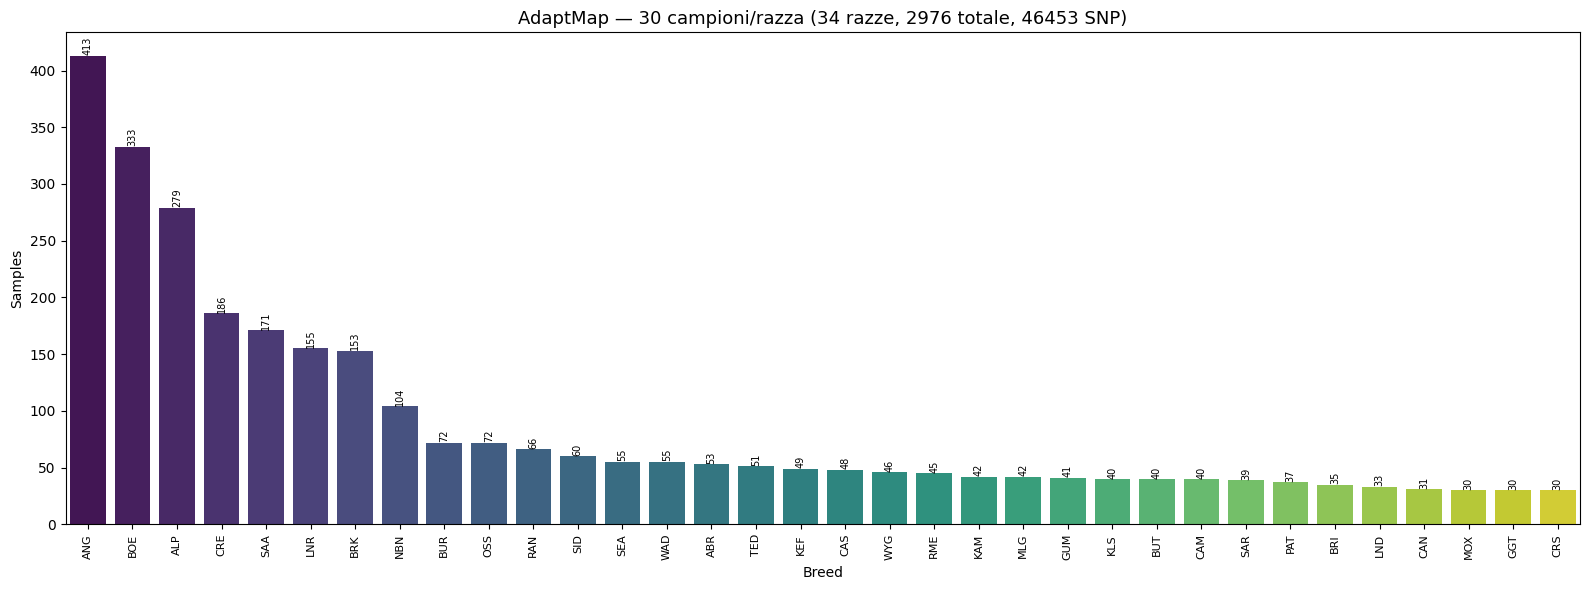

In [11]:
plot_distribution(dm.y_processed, dm.class_names,
                  title=f"AdaptMap — {SAMPLES_PER_CLASS} campioni/razza "
                        f"({dm.num_classes} razze, {len(dm.X_processed)} totale, {dm.num_snps} SNP)")


## 🚀 Training

- **1 iterazione per epoch** (full-batch)
- LR: 0.001 → ~6.7×10⁻⁶ dopo 5000 epoche (`0.001 × 0.99^500`)
- GPU A100: ~1.3 s/epoch (come riportato nel paper per il dataset cani)
- Early stopping `patience=200` come salvaguardia (non menzionato nel paper)


In [12]:
result = run_experiment(
    name       = 'Original',
    dm         = dm,
    config     = config,
    max_epochs = config['max_epochs'],
    k_folds    = config['k_folds'],
)



🧪 ESPERIMENTO: Original
   K-Fold: 3 | Max epochs: 5000 | FULL-BATCH (with size limit)


🔹 FOLD 1/3  (train=1984, val=992)
   Batch size effettivo: 512


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type                | Params | Mode 
----------------------------------------------------------
0 | augment   | GeneticAugmentation | 0      | train
1 | encoder   | GeneticEncoder      | 59.6 M | train
2 | criterion | CentroidNPairLoss   | 0      | train
----------------------------------------------------------
59.6 M    Trainable params
0         Non-trainable params
59.6 M    Total params
238.377   Total estimated model params size (MB)
12        Modules in train mode
0         Modules 

Epoch 1505: 100%|██████████| 4/4 [00:00<00:00,  5.11it/s, v_num=15, val_loss=2.260, train_loss=1.710]
   ✅ Fold 1: knn_acc@3=0.9698 | sil=0.5911

🔹 FOLD 2/3  (train=1984, val=992)
   Batch size effettivo: 512


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 931: 100%|██████████| 4/4 [00:00<00:00,  5.07it/s, v_num=16, val_loss=2.530, train_loss=2.040]
   ✅ Fold 2: knn_acc@3=0.9627 | sil=0.5076

🔹 FOLD 3/3  (train=1984, val=992)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


   Batch size effettivo: 512
Epoch 2587: 100%|██████████| 4/4 [00:00<00:00,  4.73it/s, v_num=17, val_loss=2.180, train_loss=1.600]
   ✅ Fold 3: knn_acc@3=0.9677 | sil=0.499

📊 Risultati medi (3 fold):
   knn_acc_k3 (mean): 0.9667
   knn_f1_k3 (mean): 0.9609
   silhouette (mean): 0.5326
   davies_bouldin (mean): 1.1199


In [13]:
display_cols = ['Experiment'] + [c for c in result if '(mean)' in c]
df = pd.DataFrame([{k: result[k] for k in display_cols}])
os.makedirs('results', exist_ok=True)
df.to_csv('results/adaptmap_paperfaithful.csv', index=False)

print("\n📊 RISULTATI PAPER-FAITHFUL:")
print(df.to_string(index=False))
print("\n💾 Salvato: results/adaptmap_paperfaithful.csv")



📊 RISULTATI PAPER-FAITHFUL:
Experiment  knn_acc_k3 (mean)  knn_f1_k3 (mean)  silhouette (mean)  davies_bouldin (mean)
  Original             0.9667            0.9609             0.5326                 1.1199

💾 Salvato: results/adaptmap_paperfaithful.csv


## 🌍 Visualizzazione — Proiezione Equal Earth

In [ ]:
best_Z = result.get('_best_Z')
best_y = result.get('_best_y')

if best_Z is not None:
    plot_embedding(best_Z, best_y, dm.class_names)


## 📊 Confusion Matrix KNN@3

In [ ]:
if best_Z is not None:
    plot_confusion_matrix(best_Z, best_y, dm.class_names)


## 🎯 Explainable AI — IG su Similarità al Centroide di Razza

**Domanda biologica diretta:** *"Quali SNP spingono questo animale verso il cluster della sua razza nello spazio sferico?"*

### Differenza rispetto al probe

| Approccio | Funzione target degli IG | Dipende da probe? |
|---|---|---|
| Probe LogReg/MLP | Logit del classificatore | ✅ Sì |
| **Centroide (questa cella)** | **Cosine similarity verso il centroide di razza** | ❌ No |

Il centroide di ogni razza è la **media normalizzata degli embedding** di tutti i suoi campioni sulla sfera unitaria. Gli IG misurano direttamente quanto ogni SNP contribuisce ad avvicinare l'animale al proprio cluster — senza intermediari, fedele alla geometria del modello Contrastivo.

L'analisi viene eseguita sia su un **campione singolo** sia in **media globale su tutte le razze**, e i risultati sono confrontati con l'approccio probe tramite Indice di Jaccard.

In [ ]:
# ============================================================
# IG SU COSINE SIMILARITY AL CENTROIDE DI RAZZA
# Approccio probe-free: misura diretta sulla geometria sferica
# ============================================================

from contrastive_learning.attribution import (
    EncoderToCentroid,
    select_best_checkpoint,
    compute_breed_centroids,
    compute_centroid_ig_single,
    compute_centroid_ig_batched,
    aggregate_attributions,
)

# ── Carica il miglior modello (riusa se già disponibile) ─────
if 'best_model' not in globals():
    best_ckpt_c, best_acc_c, _ = select_best_checkpoint(
        dm, "checkpoints/Original/fold_*/epoch=*-val_loss=*.ckpt"
    )
    best_model = ContrastiveGeneticModel.load_from_checkpoint(best_ckpt_c)
    device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    best_model = best_model.to(device)
    best_model.eval()
    print(f"Modello caricato: {best_ckpt_c}")
else:
    device = next(best_model.parameters()).device
    print("Riuso best_model già in memoria.")

# ── Calcola i centroidi di razza sulla sfera ─────────────────
with torch.no_grad():
    Z_all = extract_embeddings(best_model, dm.X_processed)   # (N, 3)

centroids = compute_breed_centroids(Z_all, dm.y_processed, dm.num_classes)
centroids_t = torch.FloatTensor(centroids).to(device)        # (num_classes, 3)
print(f"Centroidi calcolati per {dm.num_classes} razze.")

enc_centroid = EncoderToCentroid(
    encoder   = best_model.encoder,
    centroids = centroids_t,
).to(device).eval()

# ── Esecuzione su campione singolo ───────────────────────────
SAMPLE_IDX = 0
N_IG_STEPS = 50

sample_snps = torch.FloatTensor(dm.X_processed[SAMPLE_IDX]).unsqueeze(0).to(device)
breed_name  = dm.class_names[dm.y_processed[SAMPLE_IDX]]
target_cls  = int(dm.y_processed[SAMPLE_IDX])

print(f"\nCampione {SAMPLE_IDX} — Razza: {breed_name} (classe {target_cls})")
cos_sim_base = float((torch.FloatTensor(Z_all[SAMPLE_IDX]).to(device) *
                       centroids_t[target_cls]).sum())
print(f"Cosine similarity attuale con centroide {breed_name}: {cos_sim_base:.4f}")

with torch.no_grad():
    x_oh = GeneticAugmentation.one_hot_encode(sample_snps).float()
baseline_oh = torch.zeros_like(x_oh)

print(f"Calcolo IG centroide (n_steps={N_IG_STEPS})...")
ig_centroid, delta_c = compute_centroid_ig_single(
    enc_centroid, x_oh, target_cls,
    device=device, baseline=baseline_oh, n_steps=N_IG_STEPS,
)
print(f"IG centroide completati | conv_delta={delta_c:.5f}")

# ── Plot campione singolo ─────────────────────────────────────
snp_idx      = np.arange(len(ig_centroid))
threshold_99 = np.percentile(ig_centroid, 99)
hot_mask     = ig_centroid >= threshold_99

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(snp_idx, ig_centroid, alpha=0.25, color='mediumpurple')
ax.plot(snp_idx, ig_centroid, lw=0.5, color='mediumpurple', alpha=0.8)
ax.scatter(snp_idx[hot_mask], ig_centroid[hot_mask],
           s=20, color='red', zorder=5,
           label=f'Top 1% SNP ({hot_mask.sum()} posizioni)')
ax.axhline(threshold_99, color='red', linestyle='--', lw=1.2,
           label=f'99° percentile ({threshold_99:.5f})')
ax.set_title(f'IG Centroide — Campione {SAMPLE_IDX} ({breed_name}) | n_steps={N_IG_STEPS}',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Indice SNP (post QC/LD-pruning)', fontsize=11)
ax.set_ylabel('Importanza SNP — cosine sim verso centroide', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig(f'results/ig_centroid_{SAMPLE_IDX}_{breed_name}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato: results/ig_centroid_{SAMPLE_IDX}_{breed_name}.png")

# Top 20
top20_c = np.argsort(ig_centroid)[::-1][:20]
print(f"\nTop 20 SNP — Centroide — campione {SAMPLE_IDX} ({breed_name}):")
print(f"{'Rank':<5} {'SNP Index':<12} {'IG Score'}")
print('-' * 33)
for rank, idx in enumerate(top20_c, 1):
    print(f"{rank:<5} {idx:<12} {ig_centroid[idx]:.8f}")

# ── Jaccard: Centroide vs Probe MLP ──────────────────────────
if 'ig_mlp' in globals():
    top_centroid = set(np.where(ig_centroid >= np.percentile(ig_centroid, 99))[0])
    top_mlp_g    = set(np.where(ig_mlp     >= np.percentile(ig_mlp,     99))[0])
    jacc_c_mlp   = len(top_centroid & top_mlp_g) / len(top_centroid | top_mlp_g)
    print(f"\nJaccard Centroide vs Probe MLP: {jacc_c_mlp:.4f}")
    print(f"  Centroide: {len(top_centroid)} | MLP: {len(top_mlp_g)} | "
          f"Intersezione: {len(top_centroid & top_mlp_g)}")

# ── IG globale con centroide (batched) ────────────────────────
print("\nCalcolo IG centroide globale su tutti i campioni...")
ig_all_c = compute_centroid_ig_batched(
    model          = enc_centroid,
    X_snps         = dm.X_processed,
    target_classes = torch.LongTensor(dm.y_processed).to(device),
    device         = device,
    n_steps        = N_IG_STEPS,
    batch_size     = 32,
)
print(f"ig_all_c shape: {ig_all_c.shape}")

# Media pesata per razza
ig_global_c, ig_global_c_std = aggregate_attributions(ig_all_c, dm.y_processed, dm.num_classes)

np.save('results/ig_centroid_global_mean.npy', ig_global_c)
np.save('results/ig_centroid_global_std.npy',  ig_global_c_std)
print("Salvato: results/ig_centroid_global_mean.npy")

# ── Plot comparativo globale: Probe MLP vs Centroide ─────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

datasets = [
    (ig_global,   ig_global_std,   'IG Globale — Probe MLP',      'mediumseagreen'),
    (ig_global_c, ig_global_c_std, 'IG Globale — Centroide Razza', 'mediumpurple'),
] if 'ig_global' in globals() else [
    (ig_global_c, ig_global_c_std, 'IG Globale — Centroide Razza', 'mediumpurple'),
]

for ax, (ig_vals, ig_std, title, color) in zip(axes, datasets):
    thr  = np.percentile(ig_vals, 99)
    hot  = ig_vals >= thr
    sidx = np.arange(len(ig_vals))
    ax.fill_between(sidx, ig_vals, alpha=0.25, color=color)
    ax.plot(sidx, ig_vals, lw=0.5, color=color, alpha=0.8)
    ax.fill_between(sidx,
                    ig_vals - ig_std, ig_vals + ig_std,
                    alpha=0.12, color=color, label='±1 std tra razze')
    ax.scatter(sidx[hot], ig_vals[hot], s=20, color='red', zorder=5,
               label=f'Top 1% ({hot.sum()} SNP)')
    ax.axhline(thr, color='red', linestyle='--', lw=1.2,
               label=f'99° pct ({thr:.5f})')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Importanza SNP media inter-razza', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

axes[-1].set_xlabel('Indice SNP (post QC/LD-pruning)', fontsize=11)
plt.suptitle(f'Confronto IG Globale — Probe vs Centroide ({dm.num_classes} razze)',
             fontsize=14)
plt.tight_layout()
plt.savefig('results/ig_global_probe_vs_centroide.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: results/ig_global_probe_vs_centroide.png")

# ── Jaccard globale: Probe MLP vs Centroide ───────────────────
if 'ig_global' in globals():
    top_g_probe    = set(np.where(ig_global   >= np.percentile(ig_global,   99))[0])
    top_g_centroid = set(np.where(ig_global_c >= np.percentile(ig_global_c, 99))[0])
    jacc_global    = len(top_g_probe & top_g_centroid) / len(top_g_probe | top_g_centroid)
    print(f"\nJaccard globale Probe MLP vs Centroide: {jacc_global:.4f}")
    print(f"  Probe:     {len(top_g_probe)} SNP")
    print(f"  Centroide: {len(top_g_centroid)} SNP")
    print(f"  Intersezione: {len(top_g_probe & top_g_centroid)} SNP")

# ── Top 20 SNP globali centroide ──────────────────────────────
top20_gc = np.argsort(ig_global_c)[::-1][:20]
print(f"\nTop 20 SNP globali — Centroide (media su {dm.num_classes} razze):")
print(f"{'Rank':<5} {'SNP Index':<12} {'IG mean':<16} {'IG std':<14} {'mean/std'}")
print('-' * 55)
for rank, idx in enumerate(top20_gc, 1):
    snr = ig_global_c[idx] / (ig_global_c_std[idx] + 1e-10)
    print(f"{rank:<5} {idx:<12} {ig_global_c[idx]:.8f}   "
          f"{ig_global_c_std[idx]:.8f}   {snr:.2f}")


## 🔁 Confronto Opzionale con Risultati Naïve

In [16]:
naive_csv = 'results/contrastive_knn_comparison.csv'
if os.path.exists(naive_csv):
    df_naive   = pd.read_csv(naive_csv)
    df_compare = pd.concat([df_naive,
                            pd.DataFrame([{k: result[k] for k in display_cols}])],
                           ignore_index=True)
    print("\n📊 Confronto Naïve vs Paper-Faithful:")
    print(df_compare.to_string(index=False))
    df_compare.to_csv('results/comparison.csv', index=False)
else:
    print("ℹ️  Nessun risultato naïve trovato (esegui contrastive_adaptmap.ipynb prima).")


ℹ️  Nessun risultato naïve trovato (esegui contrastive_adaptmap.ipynb prima).
